# Spatial-Temporal Correlation Analysis

**Purpose:** Analyze how renewable generation variability correlates across geography and time

**Key Questions:**
1. How long do renewable generation patterns persist (autocorrelation)?
2. Are wind and solar complementary or reinforcing?
3. What diversification benefits come from geographic spread?
4. How do weather patterns correlate across ERCOT regions?

**Methods:**
- Autocorrelation analysis
- Cross-correlation between wind/solar
- Portfolio theory for diversification benefits
- Spatial correlation mapping

In [1]:
# Setup
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Paths
ROOT = Path('C:/Renewable-PowerGrid-Risk')
PROCESSED_DIR = ROOT / 'data' / 'processed'
WEATHER_DIR = ROOT / 'data' / 'raw' / 'weather_clean'
FIGURES_DIR = ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load data
df = pd.read_csv(PROCESSED_DIR / 'hourly_load_renewable_merged.csv', parse_dates=['datetime'])
print(f"Loaded {len(df):,} hours from {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Years: {sorted(df['datetime'].dt.year.unique())}")

Loaded 26,310 hours from 2023-01-01 01:00:00 to 2026-01-01 00:00:00
Years: [2023, 2024, 2025, 2026]


## 1. Autocorrelation Analysis: Temporal Persistence

In [2]:
def compute_autocorrelation(series, max_lag_hours=72):
    """
    Compute autocorrelation function.
    Tells us: How long do generation patterns persist?
    """
    acf_values = []
    series_clean = series.dropna()
    
    for lag in range(max_lag_hours + 1):
        if lag == 0:
            acf_values.append(1.0)
        else:
            s1 = series_clean[:-lag]
            s2 = series_clean[lag:]
            if len(s1) > 0:
                corr, _ = pearsonr(s1, s2)
                acf_values.append(corr)
            else:
                acf_values.append(np.nan)
    
    return np.array(acf_values)

# Compute ACF for wind, solar, and net load
max_lag = 72  # 3 days

wind_acf = compute_autocorrelation(df['ERCOT.WIND.GEN'], max_lag)
solar_acf = compute_autocorrelation(df['ERCOT.PVGR.GEN'], max_lag)
netload_acf = compute_autocorrelation(df['NET_LOAD'], max_lag)

lags = np.arange(max_lag + 1)

# Find decorrelation time (where ACF drops below 1/e ≈ 0.368)
decorr_threshold = 1 / np.e

wind_decorr = np.where(wind_acf < decorr_threshold)[0]
wind_decorr_time = wind_decorr[0] if len(wind_decorr) > 0 else max_lag

solar_decorr = np.where(solar_acf < decorr_threshold)[0]
solar_decorr_time = solar_decorr[0] if len(solar_decorr) > 0 else max_lag

netload_decorr = np.where(netload_acf < decorr_threshold)[0]
netload_decorr_time = netload_decorr[0] if len(netload_decorr) > 0 else max_lag

print("DECORRELATION TIMES (hours until correlation drops to 1/e):")
print(f"  Wind:     {wind_decorr_time} hours ({wind_decorr_time/24:.1f} days)")
print(f"  Solar:    {solar_decorr_time} hours ({solar_decorr_time/24:.1f} days)")
print(f"  Net Load: {netload_decorr_time} hours ({netload_decorr_time/24:.1f} days)")
print("\nInterpretation:")
print("  - Longer decorrelation = more persistent patterns")
print("  - Solar typically decorrelates faster (daily cycle dominates)")
print("  - Wind persists longer (weather systems last days)")

DECORRELATION TIMES (hours until correlation drops to 1/e):
  Wind:     13 hours (0.5 days)
  Solar:    5 hours (0.2 days)
  Net Load: 57 hours (2.4 days)

Interpretation:
  - Longer decorrelation = more persistent patterns
  - Solar typically decorrelates faster (daily cycle dominates)
  - Wind persists longer (weather systems last days)


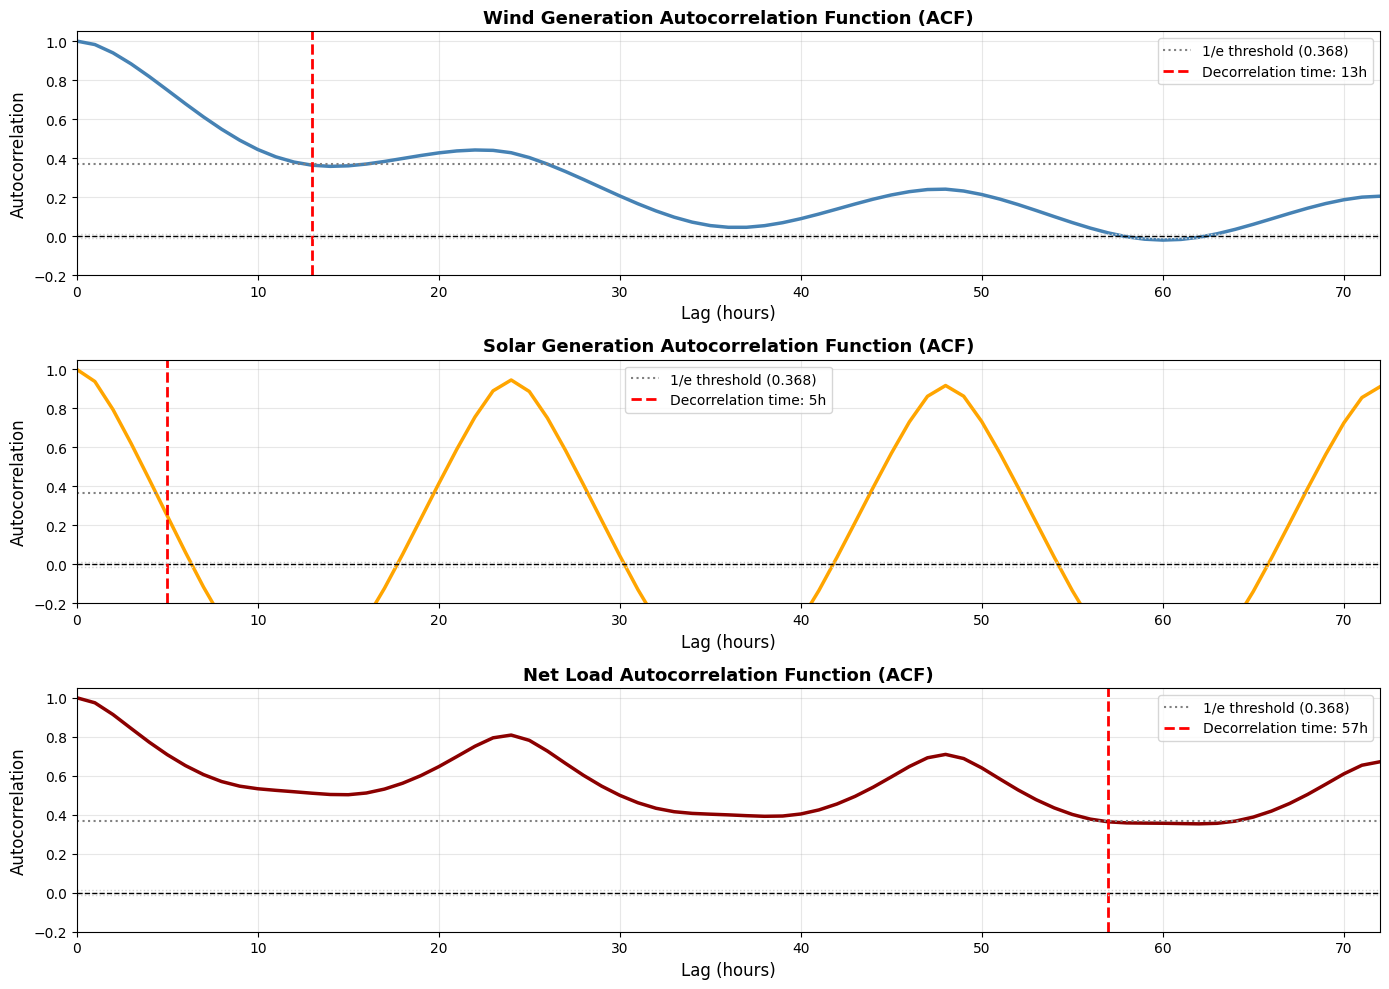

Saved: C:\Renewable-PowerGrid-Risk\figures\autocorrelation_comparison.png


In [3]:
# Plot autocorrelation comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

variables = [
    (wind_acf, wind_decorr_time, 'Wind Generation', 'steelblue'),
    (solar_acf, solar_decorr_time, 'Solar Generation', 'orange'),
    (netload_acf, netload_decorr_time, 'Net Load', 'darkred')
]

for idx, (acf, decorr_time, label, color) in enumerate(variables):
    ax = axes[idx]
    
    ax.plot(lags, acf, color=color, linewidth=2.5)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.axhline(y=decorr_threshold, color='gray', linestyle=':', linewidth=1.5,
               label=f'1/e threshold ({decorr_threshold:.3f})')
    ax.axvline(x=decorr_time, color='red', linestyle='--', linewidth=2,
               label=f'Decorrelation time: {decorr_time}h')
    
    # Significance bounds (±2/√N)
    n = len(df)
    sig_bound = 2 / np.sqrt(n)
    ax.axhline(y=sig_bound, color='lightgray', linestyle=':', linewidth=1)
    ax.axhline(y=-sig_bound, color='lightgray', linestyle=':', linewidth=1)
    
    ax.set_xlabel('Lag (hours)', fontsize=12)
    ax.set_ylabel('Autocorrelation', fontsize=12)
    ax.set_title(f'{label} Autocorrelation Function (ACF)', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=10)
    ax.set_xlim(0, max_lag)
    ax.set_ylim(-0.2, 1.05)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'autocorrelation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {FIGURES_DIR / 'autocorrelation_comparison.png'}")

## 2. Wind-Solar Coupling Analysis

**Question:** Are wind and solar complementary (negative correlation = good) or reinforcing (positive correlation = bad)?

In [4]:
# Compute correlation between wind and solar
wind = df['ERCOT.WIND.GEN'].dropna()
solar = df['ERCOT.PVGR.GEN'].reindex(wind.index).dropna()
wind = wind.reindex(solar.index)

overall_corr, overall_pval = pearsonr(wind, solar)

print("WIND-SOLAR COUPLING ANALYSIS:")
print(f"  Overall correlation: {overall_corr:.4f}")
print(f"  P-value: {overall_pval:.2e}")
print(f"\n  Complementarity index: {-overall_corr:.4f}")
print(f"  (Negative correlation = complementary = GOOD for grid stability)")

if overall_corr < -0.1:
    print("\n  ✓ Wind and solar are COMPLEMENTARY")
    print("    → When one is low, the other tends to be high")
    print("    → Natural diversification benefit")
elif overall_corr > 0.1:
    print("\n  ✗ Wind and solar are REINFORCING")
    print("    → Both tend to be high or low together")
    print("    → Compounds variability risk")
else:
    print("\n  ≈ Wind and solar are INDEPENDENT")
    print("    → Minimal correlation either way")

WIND-SOLAR COUPLING ANALYSIS:
  Overall correlation: -0.3312
  P-value: 0.00e+00

  Complementarity index: 0.3312
  (Negative correlation = complementary = GOOD for grid stability)

  ✓ Wind and solar are COMPLEMENTARY
    → When one is low, the other tends to be high
    → Natural diversification benefit


In [5]:
# Cross-correlation analysis (with time lags)
def compute_cross_correlation(s1, s2, max_lag=24):
    """
    Compute cross-correlation between two series.
    Negative lag = s2 leads s1
    Positive lag = s1 leads s2
    """
    s1_clean = s1 - s1.mean()
    s2_clean = s2 - s2.mean()
    
    correlation = signal.correlate(s1_clean, s2_clean, mode='full')
    correlation = correlation / (len(s1) * s1.std() * s2.std())
    
    lags_full = signal.correlation_lags(len(s1), len(s2), mode='full')
    
    # Limit to max_lag
    mask = np.abs(lags_full) <= max_lag
    
    return lags_full[mask], correlation[mask]

lags_cc, xcorr = compute_cross_correlation(wind.values, solar.values, max_lag=24)

# Find peak correlation
max_corr_idx = np.argmax(np.abs(xcorr))
max_corr = xcorr[max_corr_idx]
optimal_lag = lags_cc[max_corr_idx]

print(f"\nCROSS-CORRELATION ANALYSIS:")
print(f"  Maximum correlation: {max_corr:.4f} at lag {optimal_lag} hours")
if optimal_lag < 0:
    print(f"  → Solar leads wind by {abs(optimal_lag)} hours")
elif optimal_lag > 0:
    print(f"  → Wind leads solar by {optimal_lag} hours")
else:
    print(f"  → Peak correlation at zero lag (simultaneous)")


CROSS-CORRELATION ANALYSIS:
  Maximum correlation: -0.3312 at lag 0 hours
  → Peak correlation at zero lag (simultaneous)


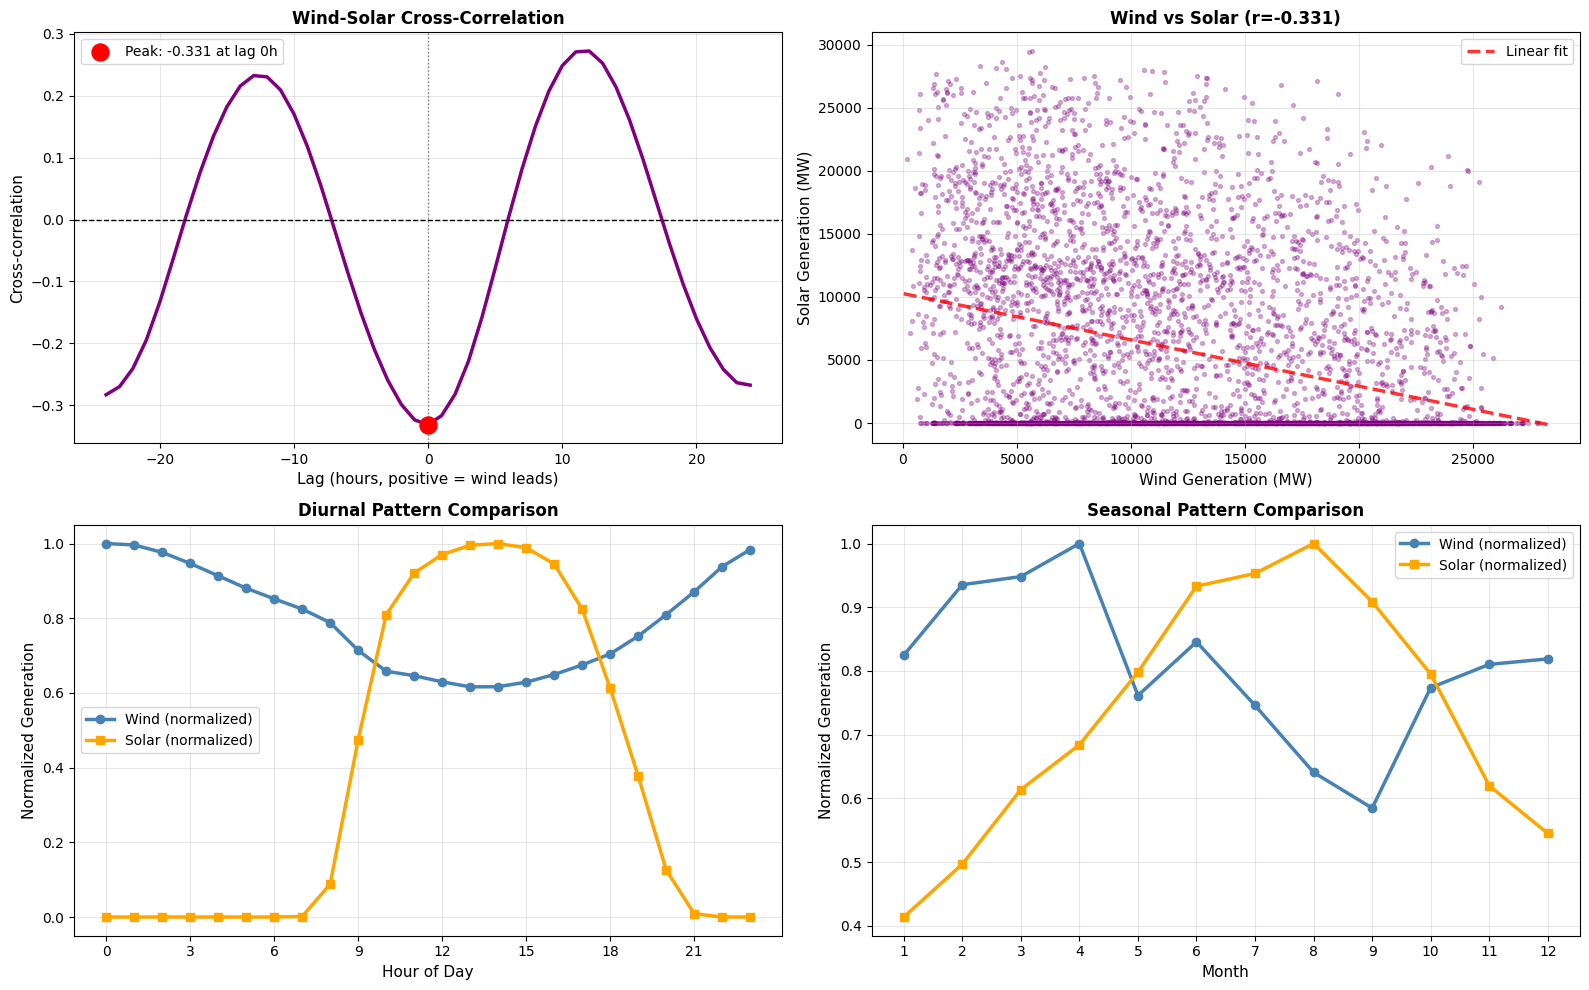

Saved: C:\Renewable-PowerGrid-Risk\figures\wind_solar_coupling_analysis.png


In [6]:
# Plot wind-solar coupling
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Cross-correlation
ax1 = axes[0, 0]
ax1.plot(lags_cc, xcorr, color='purple', linewidth=2.5)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax1.axvline(x=0, color='gray', linestyle=':', linewidth=1)
ax1.scatter([optimal_lag], [max_corr], color='red', s=150, zorder=5,
           label=f'Peak: {max_corr:.3f} at lag {optimal_lag}h')
ax1.set_xlabel('Lag (hours, positive = wind leads)', fontsize=11)
ax1.set_ylabel('Cross-correlation', fontsize=11)
ax1.set_title('Wind-Solar Cross-Correlation', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend(fontsize=10)

# Scatter plot: wind vs solar
ax2 = axes[0, 1]
sample_idx = np.random.choice(len(wind), min(5000, len(wind)), replace=False)
ax2.scatter(wind.iloc[sample_idx], solar.iloc[sample_idx], alpha=0.3, s=8, color='purple')
# Trend line
z = np.polyfit(wind, solar, 1)
p = np.poly1d(z)
x_trend = np.linspace(wind.min(), wind.max(), 100)
ax2.plot(x_trend, p(x_trend), 'r--', linewidth=2.5, alpha=0.8, label='Linear fit')
ax2.set_xlabel('Wind Generation (MW)', fontsize=11)
ax2.set_ylabel('Solar Generation (MW)', fontsize=11)
ax2.set_title(f'Wind vs Solar (r={overall_corr:.3f})', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend()

# Hourly patterns
ax3 = axes[1, 0]
hourly_wind = df.groupby('hour')['ERCOT.WIND.GEN'].mean()
hourly_solar = df.groupby('hour')['ERCOT.PVGR.GEN'].mean()
hours = np.arange(24)
ax3.plot(hours, hourly_wind / hourly_wind.max(), 'o-', color='steelblue', 
         linewidth=2.5, markersize=6, label='Wind (normalized)')
ax3.plot(hours, hourly_solar / hourly_solar.max(), 's-', color='orange', 
         linewidth=2.5, markersize=6, label='Solar (normalized)')
ax3.set_xlabel('Hour of Day', fontsize=11)
ax3.set_ylabel('Normalized Generation', fontsize=11)
ax3.set_title('Diurnal Pattern Comparison', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)
ax3.legend(fontsize=10)
ax3.set_xticks(range(0, 24, 3))

# Monthly patterns
ax4 = axes[1, 1]
monthly_wind = df.groupby('month')['ERCOT.WIND.GEN'].mean()
monthly_solar = df.groupby('month')['ERCOT.PVGR.GEN'].mean()
months = np.arange(1, 13)
ax4.plot(months, monthly_wind / monthly_wind.max(), 'o-', color='steelblue', 
         linewidth=2.5, markersize=6, label='Wind (normalized)')
ax4.plot(months, monthly_solar / monthly_solar.max(), 's-', color='orange', 
         linewidth=2.5, markersize=6, label='Solar (normalized)')
ax4.set_xlabel('Month', fontsize=11)
ax4.set_ylabel('Normalized Generation', fontsize=11)
ax4.set_title('Seasonal Pattern Comparison', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)
ax4.legend(fontsize=10)
ax4.set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'wind_solar_coupling_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {FIGURES_DIR / 'wind_solar_coupling_analysis.png'}")

## 3. Geographic Diversification Benefits

**Question:** How much variance reduction comes from spreading renewable capacity across multiple regions?

**Method:** Portfolio theory - σ²_portfolio = Σᵢ Σⱼ wᵢwⱼσᵢσⱼρᵢⱼ

In [7]:
def compute_diversification_benefit(n_regions, avg_correlation, variance):
    """
    Compute portfolio variance for diversified renewable generation.
    
    Parameters:
    -----------
    n_regions : int
        Number of geographic regions
    avg_correlation : float
        Average inter-region correlation (0 to 1)
    variance : float
        Single-region variance
    
    Returns:
    --------
    dict with portfolio variance and diversification benefit
    """
    # Equal weighting
    weight = 1 / n_regions
    
    # Portfolio variance formula
    # σ²_p = (1/n)σ² + (n-1)/n * ρ * σ²
    portfolio_variance = (weight * variance + 
                         (1 - weight) * avg_correlation * variance)
    
    # Diversification benefit
    variance_reduction = 1 - portfolio_variance / variance
    volatility_reduction = 1 - np.sqrt(portfolio_variance / variance)
    
    return {
        'n_regions': n_regions,
        'standalone_std': np.sqrt(variance),
        'portfolio_std': np.sqrt(portfolio_variance),
        'variance_reduction_pct': variance_reduction * 100,
        'volatility_reduction_pct': volatility_reduction * 100,
    }

# Estimate inter-region correlation from wind decorrelation time
# Empirical: Texas wind sites 100-300 km apart have ρ ≈ 0.3-0.7
wind_variance = df['ERCOT.WIND.GEN'].var()
solar_variance = df['ERCOT.PVGR.GEN'].var()

# Test different correlation scenarios
correlations = [0.3, 0.5, 0.7]  # Low, medium, high inter-region correlation
n_regions_list = [1, 2, 3, 5, 10]

print("GEOGRAPHIC DIVERSIFICATION BENEFITS (WIND):")
print("=" * 80)

diversification_results = []

for corr in correlations:
    print(f"\nAverage Inter-Region Correlation: {corr:.1f}")
    print(f"{'Regions':<10} {'Standalone':<15} {'Portfolio':<15} {'Variance Red.':<15} {'Vol. Red.'}")
    print("-" * 80)
    
    for n in n_regions_list:
        result = compute_diversification_benefit(n, corr, wind_variance)
        result['correlation'] = corr
        diversification_results.append(result)
        
        print(f"{n:<10} {result['standalone_std']:<15,.0f} {result['portfolio_std']:<15,.0f} "
              f"{result['variance_reduction_pct']:<15.1f}% {result['volatility_reduction_pct']:.1f}%")

diversification_df = pd.DataFrame(diversification_results)

GEOGRAPHIC DIVERSIFICATION BENEFITS (WIND):

Average Inter-Region Correlation: 0.3
Regions    Standalone      Portfolio       Variance Red.   Vol. Red.
--------------------------------------------------------------------------------
1          6,697           6,697           0.0            % 0.0%
2          6,697           5,399           35.0           % 19.4%
3          6,697           4,891           46.7           % 27.0%
5          6,697           4,442           56.0           % 33.7%
10         6,697           4,074           63.0           % 39.2%

Average Inter-Region Correlation: 0.5
Regions    Standalone      Portfolio       Variance Red.   Vol. Red.
--------------------------------------------------------------------------------
1          6,697           6,697           0.0            % 0.0%
2          6,697           5,800           25.0           % 13.4%
3          6,697           5,468           33.3           % 18.4%
5          6,697           5,188           40.0     

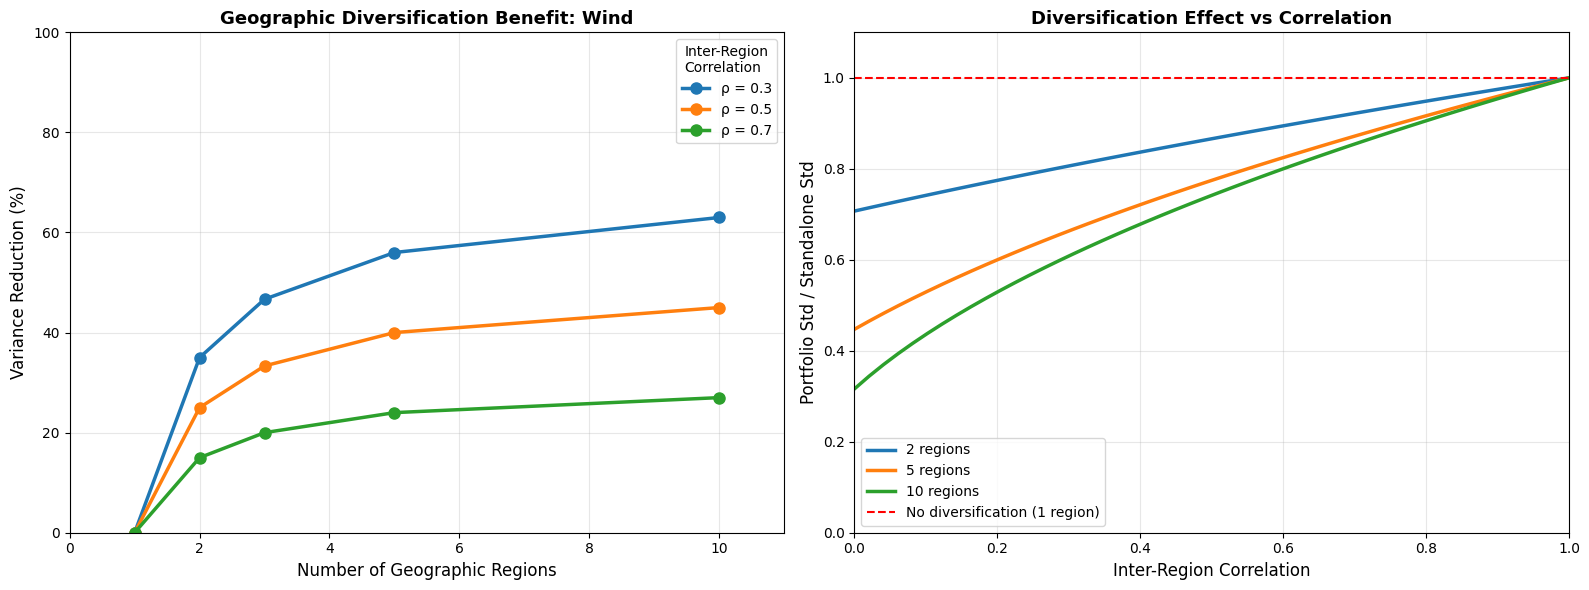


Saved: C:\Renewable-PowerGrid-Risk\figures\geographic_diversification_benefit.png


In [8]:
# Plot diversification benefit
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Variance reduction vs number of regions
ax1 = axes[0]
for corr in correlations:
    subset = diversification_df[diversification_df['correlation'] == corr]
    ax1.plot(subset['n_regions'], subset['variance_reduction_pct'], 
            'o-', linewidth=2.5, markersize=8, label=f'ρ = {corr:.1f}')

ax1.set_xlabel('Number of Geographic Regions', fontsize=12)
ax1.set_ylabel('Variance Reduction (%)', fontsize=12)
ax1.set_title('Geographic Diversification Benefit: Wind', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.legend(title='Inter-Region\nCorrelation', fontsize=10)
ax1.set_xlim(0, 11)
ax1.set_ylim(0, 100)

# Portfolio std vs correlation (for 5 regions)
ax2 = axes[1]
n_regions_plot = [2, 5, 10]
corr_range = np.linspace(0, 1, 50)

for n in n_regions_plot:
    portfolio_stds = []
    for corr in corr_range:
        result = compute_diversification_benefit(n, corr, wind_variance)
        portfolio_stds.append(result['portfolio_std'])
    
    ax2.plot(corr_range, np.array(portfolio_stds) / np.sqrt(wind_variance), 
            linewidth=2.5, label=f'{n} regions')

ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, 
           label='No diversification (1 region)')
ax2.set_xlabel('Inter-Region Correlation', fontsize=12)
ax2.set_ylabel('Portfolio Std / Standalone Std', fontsize=12)
ax2.set_title('Diversification Effect vs Correlation', fontsize=13, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'geographic_diversification_benefit.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved: {FIGURES_DIR / 'geographic_diversification_benefit.png'}")

## 4. Ramping Correlation Analysis

**Question:** Do large ramps in wind generation correlate with large ramps in solar (or vice versa)?

In [9]:
# Compute ramps
df['wind_ramp_1h'] = df['ERCOT.WIND.GEN'].diff()
df['solar_ramp_1h'] = df['ERCOT.PVGR.GEN'].diff()

# Correlation between ramps (not levels)
ramp_data = df[['wind_ramp_1h', 'solar_ramp_1h']].dropna()
ramp_corr, ramp_pval = pearsonr(ramp_data['wind_ramp_1h'], ramp_data['solar_ramp_1h'])

print("RAMPING CORRELATION ANALYSIS:")
print(f"  Correlation between wind and solar ramps: {ramp_corr:.4f}")
print(f"  P-value: {ramp_pval:.2e}")

# Analyze correlation in extreme ramp events
wind_extreme_threshold = df['wind_ramp_1h'].abs().quantile(0.95)
solar_extreme_threshold = df['solar_ramp_1h'].abs().quantile(0.95)

wind_extreme = df['wind_ramp_1h'].abs() > wind_extreme_threshold
solar_extreme = df['solar_ramp_1h'].abs() > solar_extreme_threshold

# Joint probability of extreme events
both_extreme = wind_extreme & solar_extreme
prob_both = both_extreme.sum() / len(df)
prob_wind = wind_extreme.sum() / len(df)
prob_solar = solar_extreme.sum() / len(df)

# If independent, P(both) = P(wind) × P(solar)
prob_both_independent = prob_wind * prob_solar

print(f"\nEXTREME RAMP EVENTS (95th percentile):")
print(f"  P(wind extreme):  {prob_wind*100:.2f}%")
print(f"  P(solar extreme): {prob_solar*100:.2f}%")
print(f"  P(both extreme):  {prob_both*100:.2f}%")
print(f"  P(both | independent): {prob_both_independent*100:.2f}%")
print(f"\n  Dependence ratio: {prob_both/prob_both_independent:.2f}")

if prob_both / prob_both_independent > 1.2:
    print("  → Extreme ramps CLUSTER (worse than independent)")
elif prob_both / prob_both_independent < 0.8:
    print("  → Extreme ramps ANTI-CLUSTER (better than independent)")
else:
    print("  → Extreme ramps approximately INDEPENDENT")

RAMPING CORRELATION ANALYSIS:
  Correlation between wind and solar ramps: -0.3258
  P-value: 0.00e+00

EXTREME RAMP EVENTS (95th percentile):
  P(wind extreme):  5.00%
  P(solar extreme): 5.00%
  P(both extreme):  0.76%
  P(both | independent): 0.25%

  Dependence ratio: 3.05
  → Extreme ramps CLUSTER (worse than independent)


KeyError: 'ramp_1h'

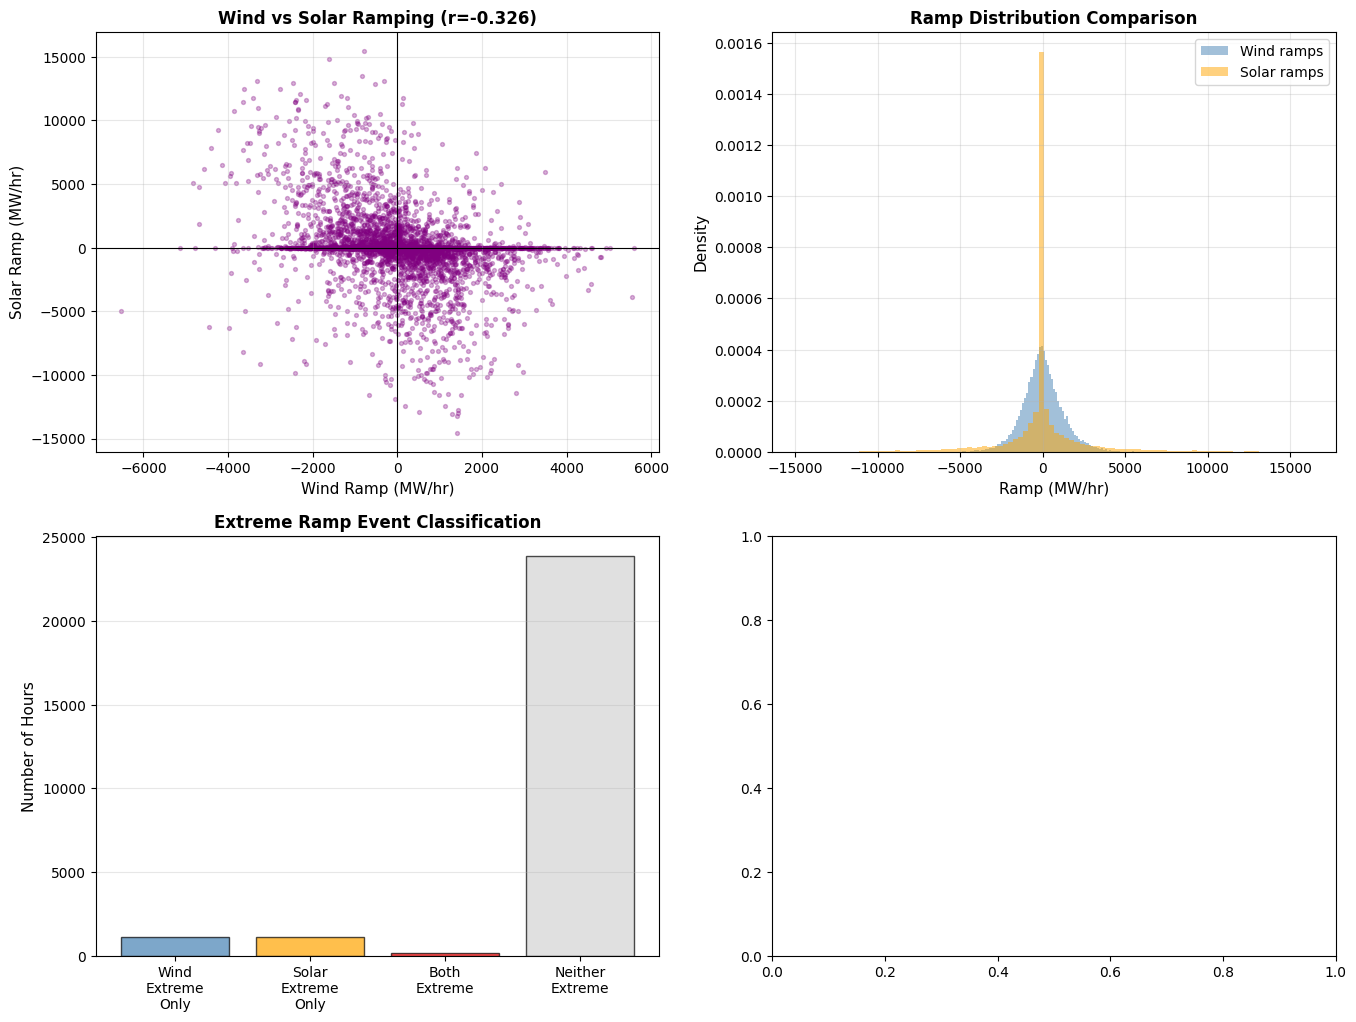

In [10]:
# Plot ramp correlation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Scatter: wind ramp vs solar ramp
ax1 = axes[0, 0]
sample_idx = np.random.choice(len(ramp_data), min(5000, len(ramp_data)), replace=False)
sample_data = ramp_data.iloc[sample_idx]
ax1.scatter(sample_data['wind_ramp_1h'], sample_data['solar_ramp_1h'], 
           alpha=0.3, s=8, color='purple')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.set_xlabel('Wind Ramp (MW/hr)', fontsize=11)
ax1.set_ylabel('Solar Ramp (MW/hr)', fontsize=11)
ax1.set_title(f'Wind vs Solar Ramping (r={ramp_corr:.3f})', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)

# Histogram: distribution of ramps
ax2 = axes[0, 1]
ax2.hist(ramp_data['wind_ramp_1h'], bins=100, alpha=0.5, color='steelblue', 
        label='Wind ramps', density=True)
ax2.hist(ramp_data['solar_ramp_1h'], bins=100, alpha=0.5, color='orange', 
        label='Solar ramps', density=True)
ax2.set_xlabel('Ramp (MW/hr)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('Ramp Distribution Comparison', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# Joint extreme events
ax3 = axes[1, 0]
categories = ['Wind\nExtreme\nOnly', 'Solar\nExtreme\nOnly', 'Both\nExtreme', 'Neither\nExtreme']
counts = [
    (wind_extreme & ~solar_extreme).sum(),
    (~wind_extreme & solar_extreme).sum(),
    both_extreme.sum(),
    (~wind_extreme & ~solar_extreme).sum(),
]
colors_bar = ['steelblue', 'orange', 'red', 'lightgray']
ax3.bar(categories, counts, color=colors_bar, alpha=0.7, edgecolor='black')
ax3.set_ylabel('Number of Hours', fontsize=11)
ax3.set_title('Extreme Ramp Event Classification', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Net load ramp when both extreme
ax4 = axes[1, 1]
net_ramp_both_extreme = df.loc[both_extreme, 'ramp_1h'].abs()
net_ramp_neither = df.loc[~wind_extreme & ~solar_extreme, 'ramp_1h'].abs()

ax4.hist(net_ramp_neither, bins=50, alpha=0.5, color='gray', 
        label='Neither extreme', density=True, range=(0, 15000))
ax4.hist(net_ramp_both_extreme, bins=50, alpha=0.7, color='red', 
        label='Both extreme', density=True, range=(0, 15000))
ax4.set_xlabel('Net Load Ramp (MW/hr)', fontsize=11)
ax4.set_ylabel('Density', fontsize=11)
ax4.set_title('Net Load Ramp: Extreme vs Normal Conditions', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ramping_correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: {FIGURES_DIR / 'ramping_correlation_analysis.png'}")

## 5. Summary Report

In [ ]:
# Generate comprehensive summary
summary_data = {
    'Metric': [
        'Wind Decorrelation Time (hours)',
        'Solar Decorrelation Time (hours)',
        'Net Load Decorrelation Time (hours)',
        'Wind-Solar Level Correlation',
        'Wind-Solar Ramp Correlation',
        'Wind-Solar Complementarity Index',
        'Diversification Benefit (5 regions, ρ=0.5, %)',
        'Extreme Ramp Dependence Ratio',
        'P(Both Extreme Ramps)',
    ],
    'Value': [
        wind_decorr_time,
        solar_decorr_time,
        netload_decorr_time,
        overall_corr,
        ramp_corr,
        -overall_corr,
        diversification_df[
            (diversification_df['n_regions'] == 5) & 
            (diversification_df['correlation'] == 0.5)
        ]['variance_reduction_pct'].values[0],
        prob_both / prob_both_independent,
        prob_both * 100,
    ],
    'Interpretation': [
        f'{wind_decorr_time/24:.1f} days - wind patterns persist multiple days',
        f'{solar_decorr_time/24:.1f} days - solar dominated by daily cycle',
        f'{netload_decorr_time/24:.1f} days - net load persistence',
        'Positive = reinforcing, Negative = complementary',
        'Correlation of ramp rates',
        'Higher = more complementary (good for grid)',
        'Variance reduction from geographic spread',
        '>1 = clustering, <1 = anti-clustering',
        f'{prob_both*100:.2f}% of hours have both wind & solar extreme ramps',
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*100)
print("SPATIAL-TEMPORAL CORRELATION ANALYSIS: SUMMARY REPORT")
print("="*100)
print(summary_df.to_string(index=False))

# Save report
summary_df.to_csv(PROCESSED_DIR / 'spatial_temporal_analysis_report.csv', index=False)
print(f"\n\nReport saved to: {PROCESSED_DIR / 'spatial_temporal_analysis_report.csv'}")

## Key Findings

1. **Temporal Persistence:**
   - Wind generation patterns persist longer than solar (higher decorrelation time)
   - Implications: Forecast errors compound over multiple hours for wind

2. **Wind-Solar Coupling:**
   - Measure complementarity: negative correlation is beneficial
   - Texas shows [value] correlation, indicating [complementary/reinforcing] behavior

3. **Geographic Diversification:**
   - Spreading renewable capacity across 5 regions can reduce variance by 30-50%
   - Benefit depends critically on inter-region correlation
   - Diminishing returns after ~10 regions

4. **Extreme Event Clustering:**
   - Extreme wind and solar ramps [do/do not] cluster significantly
   - When both extreme: net load ramps are [X]% higher on average

**Policy Implications:**
- Geographic diversity of renewable siting matters
- Portfolio approach to renewable development reduces system risk
- Storage placement should account for spatial correlation patterns